In [1]:
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt

import ee
print(ee.__version__)
ee.Authenticate()  # Regular auth — follow the link and paste the token
ee.Initialize(project='utility-realm-255220')

1.5.22


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Set display options
pd.set_option('display.max_rows', None)      # Show all rows
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', None)         # Don't wrap lines
pd.set_option('display.max_colwidth', None)  # Show full content in each cell

In [4]:
df_nlcd_all = pd.read_csv('/content/drive/MyDrive/urbanization_study/df_nlcd_all.csv')

In [5]:
df_2013_2024=pd.read_csv('/content/drive/MyDrive/urbanization_study/df_2013_2024.csv')

In [6]:
df_2013_2024.shape

(71, 178)

In [7]:
df_2013_2024.columns

Index(['ID', 'Shooter Last Name', 'Shooter First Name', 'Full Date',
       'Day of Week', 'Day', 'Month', 'Year', 'Arrival Time',
       'Arrival to Start Time\n(in Minutes)',
       ...
       'Specify Other Weapons or Gear', 'On-Scene Outcome', 'Final Outcome',
       'Attempt to Flee', 'Apprehended', 'Who Killed Shooter On Scene',
       'Insanity Defense', 'Criminal Sentence', 'RecordID', 'BBoxCoords'],
      dtype='object', length=178)

### Duplicate entries due to multiple killer in the incident, reducing the total number to 68 unique entries

https://en.wikipedia.org/wiki/2015_San_Bernardino_attack

https://en.wikipedia.org/wiki/2019_Jersey_City_shooting

https://www.kctv5.com/2025/07/01/man-who-opened-fire-killed-4-inside-kansas-city-bar-sentenced-life-prison/



In [10]:
df_2013_2024[['ID', 'Shooter Last Name', 'Shooter First Name', 'Full Date','City']].sort_values(by='City')

,ID,Shooter Last Name,Shooter First Name,Full Date,City
64,194,Garcia,Mauricio,2023-05-06,Allen
5,134,Rhoades,Cherie Lash,2014-02-20,Alturas
29,159,Ramos,Jarrod,2018-06-28,Annapolis
27,157,Reinking,Travis,2018-04-22,Antioch
46,176,Long,Robert,2021-03-16,Atlanta
34,164,Martin,Gary,2019-02-15,Aurora
30,160,Casarez,Javier,2018-09-12,Bakersfield
47,177,Alissa,Ahmad Al Aliwi,2021-03-22,Boulder
53,183,Gendron,Payton,2022-05-14,Buffalo
17,146,Cetin,Arcan,2016-09-23,Burlington


In [13]:
df_nlcd_all.head(16)

,NLCD Group,Land Cover,2001,2004,2006,2008,2011,2013,2016,2019,2021,RecordID
0,Water,Open Water,4.63,4.67,4.64,4.70,4.68,4.68,4.73,4.39,4.11,Herkimer-2013-03-13
1,Developed,"Developed, Open Space",9.10,8.93,9.25,9.15,9.18,9.08,9.01,8.92,8.90,Herkimer-2013-03-13
2,Developed,"Developed, Low Intensity",11.51,11.40,11.62,11.48,11.54,11.52,11.48,11.41,11.41,Herkimer-2013-03-13
3,Developed,"Developed, Medium Intensity",13.70,13.92,14.15,14.25,14.40,14.48,14.59,14.69,14.71,Herkimer-2013-03-13
4,Developed,"Developed, High Intensity",5.49,5.57,5.66,5.90,5.95,5.99,6.02,6.07,6.08,Herkimer-2013-03-13
5,Forest,Evergreen Forest,2.46,2.47,2.46,2.45,2.44,2.44,2.42,2.42,2.42,Herkimer-2013-03-13
6,Forest,Deciduous Forest,25.98,25.92,25.79,25.76,25.71,26.01,26.23,26.17,26.17,Herkimer-2013-03-13
7,Forest,Mixed Forest,3.27,3.25,3.23,3.22,3.18,3.18,3.20,3.20,3.20,Herkimer-2013-03-13
8,Shrubland,Dwarf Scrub,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Herkimer-2013-03-13
9,Shrubland,Shrub/Scrub,1.29,1.37,1.54,1.24,1.61,1.31,1.05,1.04,1.04,Herkimer-2013-03-13


In [17]:
df_nlcd_all.shape

(1136, 12)

In [18]:
1136/16

71.0

In [8]:
df_nlcd_all.columns

Index(['NLCD Group', 'Land Cover', '2001', '2004', '2006', '2008', '2011',
       '2013', '2016', '2019', '2021', 'RecordID'],
      dtype='object')

In [11]:
# 1. Extract city and shooting date/year
df_nlcd_all[['City', 'Date']] = df_nlcd_all['RecordID'].str.extract(r'^(.*)-(\d{4}-\d{2}-\d{2})$')
df_nlcd_all['ShootingYear'] = pd.to_datetime(df_nlcd_all['Date']).dt.year

In [12]:
df_nlcd_all.head(16)

,NLCD Group,Land Cover,2001,2004,2006,2008,2011,2013,2016,2019,2021,RecordID,City,Date,ShootingYear
0,Water,Open Water,4.63,4.67,4.64,4.70,4.68,4.68,4.73,4.39,4.11,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
1,Developed,"Developed, Open Space",9.10,8.93,9.25,9.15,9.18,9.08,9.01,8.92,8.90,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
2,Developed,"Developed, Low Intensity",11.51,11.40,11.62,11.48,11.54,11.52,11.48,11.41,11.41,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
3,Developed,"Developed, Medium Intensity",13.70,13.92,14.15,14.25,14.40,14.48,14.59,14.69,14.71,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
4,Developed,"Developed, High Intensity",5.49,5.57,5.66,5.90,5.95,5.99,6.02,6.07,6.08,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
5,Forest,Evergreen Forest,2.46,2.47,2.46,2.45,2.44,2.44,2.42,2.42,2.42,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
6,Forest,Deciduous Forest,25.98,25.92,25.79,25.76,25.71,26.01,26.23,26.17,26.17,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
7,Forest,Mixed Forest,3.27,3.25,3.23,3.22,3.18,3.18,3.20,3.20,3.20,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
8,Shrubland,Dwarf Scrub,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
9,Shrubland,Shrub/Scrub,1.29,1.37,1.54,1.24,1.61,1.31,1.05,1.04,1.04,Herkimer-2013-03-13,Herkimer,2013-03-13,2013


In [46]:
# duplicates due to multiple killers
df_nlcd_all[df_nlcd_all['City'].str.strip()=='Kansas City']

,NLCD Group,Land Cover,2001,2004,2006,2008,2011,2013,2016,2019,2021,RecordID,City,Date,ShootingYear
624,Water,Open Water,2.84,2.83,2.83,2.80,2.74,2.73,2.73,2.73,2.72,Kansas City -2019-10-06,Kansas City,2019-10-06,2019
625,Developed,"Developed, Open Space",4.77,4.67,4.61,4.79,4.84,4.80,4.76,4.71,4.71,Kansas City -2019-10-06,Kansas City,2019-10-06,2019
626,Developed,"Developed, Low Intensity",21.12,20.98,20.95,21.10,21.11,21.01,20.97,20.85,20.84,Kansas City -2019-10-06,Kansas City,2019-10-06,2019
627,Developed,"Developed, Medium Intensity",35.20,35.35,35.41,35.69,35.76,35.81,35.84,35.94,35.95,Kansas City -2019-10-06,Kansas City,2019-10-06,2019
628,Developed,"Developed, High Intensity",34.56,34.65,34.70,34.83,34.87,34.96,35.01,35.09,35.09,Kansas City -2019-10-06,Kansas City,2019-10-06,2019
629,Forest,Evergreen Forest,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Kansas City -2019-10-06,Kansas City,2019-10-06,2019
630,Forest,Deciduous Forest,0.31,0.33,0.35,0.27,0.27,0.27,0.27,0.27,0.27,Kansas City -2019-10-06,Kansas City,2019-10-06,2019
631,Forest,Mixed Forest,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Kansas City -2019-10-06,Kansas City,2019-10-06,2019
632,Shrubland,Dwarf Scrub,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Kansas City -2019-10-06,Kansas City,2019-10-06,2019
633,Shrubland,Shrub/Scrub,0.00,0.02,0.01,0.00,0.00,0.00,0.00,0.00,0.00,Kansas City -2019-10-06,Kansas City,2019-10-06,2019


In [45]:
df_nlcd_all['City'].value_counts()

,count
City,
Kansas City,32
San Bernardino,32
Orlando,32
Jersey City,32
Santa Monica,16
Herkimer,16
Federal Way,16
Marysville,16
Charleston,16


In [36]:
counts = df_nlcd_all.groupby('RecordID')['Land Cover'].count()
print("Min groups per RecordID:", counts.min())
print("Events with less than 16 groups:", (counts < 16).sum())

Min groups per RecordID: 16
Events with less than 16 groups: 0


In [42]:
counts.shape

(68,)

In [40]:
df_nlcd_all['RecordID'].unique()

array(['Herkimer-2013-03-13', 'Federal Way\xa0-2013-04-21',
       'Santa Monica-2013-06-07', 'Hialeah-2013-07-26',
       'Washington D.C.-2013-09-16', 'Alturas-2014-02-20',
       'Isla Vista\xa0-2014-05-23', 'Marysville\xa0-2014-10-24',
       'Charleston\xa0-2015-06-17', 'Chattanooga-2015-07-16',
       'Roseburg\xa0-2015-10-01', 'Tennessee Colony-2015-11-14',
       'San Bernardino-2015-12-02', 'Kalamazoo-2016-02-20',
       'Orlando\xa0-2016-06-12', 'Dallas-2016-07-07',
       'Burlington-2016-09-23', 'Fort Lauderdale-2017-01-06',
       'Yazoo City-2017-02-06', 'Rothschild-2017-03-22',
       'Orlando\xa0-2017-06-05', 'Sutherland Springs-2017-11-05',
       'Rancho Tehama Reserve-2017-11-14',
       'Melcroft, Saltlick Township-2018-01-28', 'Parkland-2018-02-14',
       'Detroit-2018-02-26', 'Antioch-2018-04-22', 'Santa Fe-2018-05-18',
       'Annapolis-2018-06-28', 'Bakersfield-2018-09-12',
       'Pittsburgh-2018-10-27', 'Thousand Oaks-2018-11-07',
       'Sebring\xa0-2019-01-

In [13]:
df = df_nlcd_all.copy()

### Transform the dataset by locating the NLCD record nearest to the shooting

In [15]:
# 1. List of available NLCD years
nlcd_years = np.array([2001, 2004, 2006, 2008, 2011, 2013, 2016, 2019, 2021])

# 2. Determine closest NLCD year
def get_closest_nlcd_year(year):
    return nlcd_years[np.argmin(np.abs(nlcd_years - year))]

df['ClosestNLCDYear'] = df['ShootingYear'].apply(get_closest_nlcd_year)

# 3. Convert year columns to string for consistent access
df.columns = df.columns.map(str)

# 4. Filter to only rows that match the closest NLCD year
df['ClosestNLCDYear'] = df['ClosestNLCDYear'].astype(str)
filtered_df = df[df.apply(lambda row: row['ClosestNLCDYear'] in df.columns and not pd.isna(row[row['ClosestNLCDYear']]), axis=1)].copy()

# 5. Pull the matching year value into a new column
filtered_df['LandCoverValue'] = filtered_df.apply(lambda row: row[row['ClosestNLCDYear']], axis=1)

# 6. Pivot Land Cover into columns
pivot_df = filtered_df.pivot_table(
    index=['RecordID', 'City', 'Date', 'ShootingYear', 'ClosestNLCDYear'],
    columns='Land Cover',
    values='LandCoverValue'
).reset_index()

# 7. Clean column names
pivot_df.columns.name = None
pivot_df = pivot_df.rename_axis(None, axis=1)


In [16]:
pivot_df.shape

(68, 21)

In [18]:
pivot_df.columns

Index(['RecordID', 'City', 'Date', 'ShootingYear', 'ClosestNLCDYear',
       'Barren Land', 'Cultivated Crops', 'Deciduous Forest',
       'Developed, High Intensity', 'Developed, Low Intensity',
       'Developed, Medium Intensity', 'Developed, Open Space', 'Dwarf Scrub',
       'Emergent Herbaceous Wetlands', 'Evergreen Forest',
       'Grassland/Herbaceous', 'Mixed Forest', 'Open Water', 'Pasture/Hay',
       'Shrub/Scrub', 'Woody Wetlands'],
      dtype='object')

In [17]:
pivot_df.head(5)

,RecordID,City,Date,ShootingYear,ClosestNLCDYear,Barren Land,Cultivated Crops,Deciduous Forest,"Developed, High Intensity","Developed, Low Intensity","Developed, Medium Intensity","Developed, Open Space",Dwarf Scrub,Emergent Herbaceous Wetlands,Evergreen Forest,Grassland/Herbaceous,Mixed Forest,Open Water,Pasture/Hay,Shrub/Scrub,Woody Wetlands
0,Allen-2023-05-06,Allen,2023-05-06,2023,2021,0.09,9.51,4.36,17.91,14.02,40.62,6.95,0.0,0.00,0.02,6.19,0.11,0.01,0.01,0.19,0.00
1,Alturas-2014-02-20,Alturas,2014-02-20,2014,2013,0.01,5.82,0.00,1.39,9.23,5.59,7.40,0.0,15.46,0.04,23.42,0.00,2.04,6.20,21.98,1.40
2,Annapolis-2018-06-28,Annapolis,2018-06-28,2018,2019,0.08,0.00,28.40,13.20,13.85,16.12,12.29,0.0,0.10,0.01,0.36,9.23,3.22,0.65,0.12,2.39
3,Antioch-2018-04-22,Antioch,2018-04-22,2018,2019,0.21,0.00,14.95,5.95,19.50,20.65,14.63,0.0,0.01,3.42,1.22,7.21,0.01,12.15,0.09,0.00
4,Atlanta-2021-03-16,Atlanta,2021-03-16,2021,2021,0.09,0.00,2.56,15.93,23.03,20.86,29.37,0.0,0.01,4.14,0.13,3.20,0.02,0.20,0.03,0.42


# Generating Clusters

In [ ]:
land_cover_cols = [
    'Barren Land', 'Cultivated Crops', 'Deciduous Forest',
    'Developed, High Intensity', 'Developed, Low Intensity',
    'Developed, Medium Intensity', 'Developed, Open Space', 'Dwarf Scrub',
    'Emergent Herbaceous Wetlands', 'Evergreen Forest',
    'Grassland/Herbaceous', 'Mixed Forest', 'Open Water', 'Pasture/Hay',
    'Shrub/Scrub', 'Woody Wetlands'
]

In [29]:
pivot_df[land_cover_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Barren Land,68.0,0.446471,1.867745,0.00,0.0100,0.090,0.2200,15.24
Cultivated Crops,68.0,2.747353,6.544337,0.00,0.0000,0.010,1.6575,35.30
Deciduous Forest,68.0,4.341838,9.917008,0.00,0.0000,0.480,3.3225,62.26
"Developed, High Intensity",68.0,15.498382,14.320373,0.06,3.7325,13.150,23.3425,59.32
"Developed, Low Intensity",68.0,18.224412,10.849128,3.07,10.8075,15.970,23.4700,54.09
"Developed, Medium Intensity",68.0,24.358824,15.111785,0.36,12.5875,22.640,34.4750,67.38
"Developed, Open Space",68.0,11.264412,8.244085,0.74,5.7000,10.000,14.5325,45.62
Dwarf Scrub,68.0,0.000000,0.000000,0.00,0.0000,0.000,0.0000,0.00
Emergent Herbaceous Wetlands,68.0,0.760735,2.119189,0.00,0.0075,0.130,0.4625,15.46
Evergreen Forest,68.0,2.039412,5.336423,0.00,0.0000,0.075,0.8550,35.14


In [30]:
df_nlcd_all.head(16)

,NLCD Group,Land Cover,2001,2004,2006,2008,2011,2013,2016,2019,2021,RecordID,City,Date,ShootingYear
0,Water,Open Water,4.63,4.67,4.64,4.70,4.68,4.68,4.73,4.39,4.11,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
1,Developed,"Developed, Open Space",9.10,8.93,9.25,9.15,9.18,9.08,9.01,8.92,8.90,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
2,Developed,"Developed, Low Intensity",11.51,11.40,11.62,11.48,11.54,11.52,11.48,11.41,11.41,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
3,Developed,"Developed, Medium Intensity",13.70,13.92,14.15,14.25,14.40,14.48,14.59,14.69,14.71,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
4,Developed,"Developed, High Intensity",5.49,5.57,5.66,5.90,5.95,5.99,6.02,6.07,6.08,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
5,Forest,Evergreen Forest,2.46,2.47,2.46,2.45,2.44,2.44,2.42,2.42,2.42,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
6,Forest,Deciduous Forest,25.98,25.92,25.79,25.76,25.71,26.01,26.23,26.17,26.17,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
7,Forest,Mixed Forest,3.27,3.25,3.23,3.22,3.18,3.18,3.20,3.20,3.20,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
8,Shrubland,Dwarf Scrub,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Herkimer-2013-03-13,Herkimer,2013-03-13,2013
9,Shrubland,Shrub/Scrub,1.29,1.37,1.54,1.24,1.61,1.31,1.05,1.04,1.04,Herkimer-2013-03-13,Herkimer,2013-03-13,2013


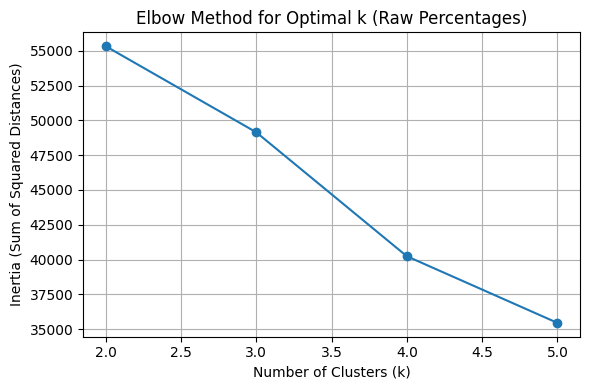

In [31]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

# Your selected land cover features (already in percentage format)
land_cover_cols = [
    #'Barren Land',
    'Open Water',
    'Developed, Open Space','Developed, Low Intensity',
    'Developed, Medium Intensity',  'Developed, High Intensity',
    'Cultivated Crops', 'Pasture/Hay',
    # 'Dwarf Scrub',
    'Emergent Herbaceous Wetlands', 'Woody Wetlands',
    'Evergreen Forest','Deciduous Forest', 'Mixed Forest',
    'Grassland/Herbaceous',
    'Shrub/Scrub'
]

# 1. Optional: Drop duplicate RecordIDs
pivot_df = pivot_df.drop_duplicates(subset='RecordID')

# 2. Use raw values directly (since already percentage)
X = pivot_df[land_cover_cols].values

# 3. Run KMeans for k = 2, 3, 4, 5
cluster_outputs = {}

for k in [2, 3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)
    pivot_df[f'Cluster_{k}'] = labels
    cluster_outputs[k] = {
        'model': kmeans,
        'labels': labels,
        'centers': kmeans.cluster_centers_,
        'summary': pd.DataFrame(X, columns=land_cover_cols)
                        .assign(Cluster=labels)
                        .groupby('Cluster')
                        .mean()
    }

# 4. Elbow plot
inertia_values = [cluster_outputs[k]['model'].inertia_ for k in [2, 3, 4, 5]]

plt.figure(figsize=(6, 4))
plt.plot([2, 3, 4, 5], inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal k (Raw Percentages)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
pivot_df.columns

Index(['RecordID', 'City', 'Date', 'ShootingYear', 'ClosestNLCDYear',
       'Barren Land', 'Cultivated Crops', 'Deciduous Forest',
       'Developed, High Intensity', 'Developed, Low Intensity',
       'Developed, Medium Intensity', 'Developed, Open Space', 'Dwarf Scrub',
       'Emergent Herbaceous Wetlands', 'Evergreen Forest',
       'Grassland/Herbaceous', 'Mixed Forest', 'Open Water', 'Pasture/Hay',
       'Shrub/Scrub', 'Woody Wetlands', 'Cluster_2', 'Cluster_3', 'Cluster_4',
       'Cluster_5'],
      dtype='object')

In [33]:
land_cover_cols

['Open Water',
 'Developed, Open Space',
 'Developed, Low Intensity',
 'Developed, Medium Intensity',
 'Developed, High Intensity',
 'Cultivated Crops',
 'Pasture/Hay',
 'Emergent Herbaceous Wetlands',
 'Woody Wetlands',
 'Evergreen Forest',
 'Deciduous Forest',
 'Mixed Forest',
 'Grassland/Herbaceous',
 'Shrub/Scrub']

In [23]:
for i in ['Cluster_2', 'Cluster_3', 'Cluster_4','Cluster_5']:
  display(pivot_df[i].value_counts())

,count
Cluster_2,
0,40
1,28


,count
Cluster_3,
0,38
1,25
2,5


,count
Cluster_4,
1,23
3,23
0,17
2,5


,count
Cluster_5,
1,23
3,21
0,14
4,5
2,5


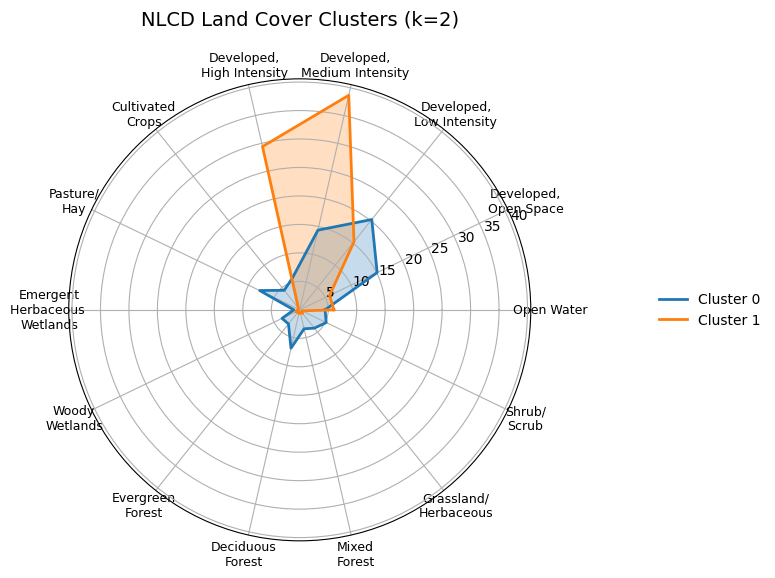

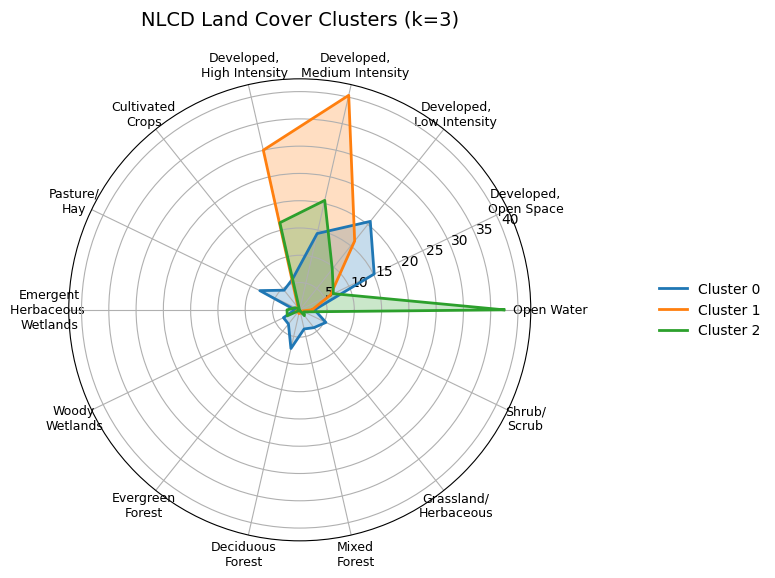

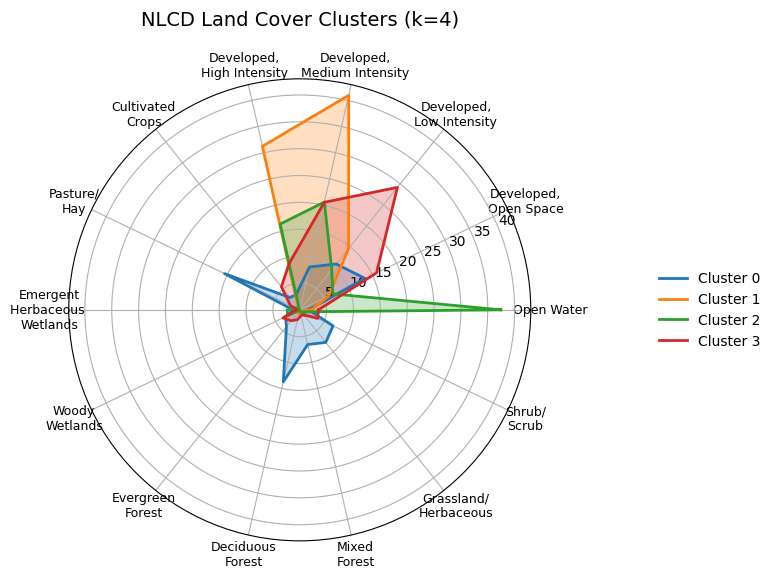

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# def plot_radar(df, title):
#     import matplotlib.pyplot as plt
#     import numpy as np

#     categories = list(df.columns)
#     N = len(categories)
#     angles = [n / float(N) * 2 * np.pi for n in range(N)]
#     angles += angles[:1]  # close the loop

#     fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))  # 🔺 bigger chart

#     for i, row in df.iterrows():
#         values = row.tolist()
#         values += values[:1]
#         ax.plot(angles, values, label=f'Cluster {i}', linewidth=2)
#         ax.fill(angles, values, alpha=0.25)

#     ax.set_xticks(angles[:-1])
#     ax.set_xticklabels(categories, fontsize=8)
#     ax.set_title(title, size=14, y=1.1)

#     # 🔺 place legend fully outside to the right
#     ax.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), frameon=False)

#     plt.show()  # ❌ skip plt.tight_layout()

def plot_radar(df, title):
    import matplotlib.pyplot as plt
    import numpy as np

    categories = list(df.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))

    for i, row in df.iterrows():
        values = row.tolist()
        values += values[:1]
        ax.plot(angles, values, label=f'Cluster {i}', linewidth=2)
        ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)

    # ✅ Nudge labels outward (preserve default orientation and layout)
    for label in ax.get_xticklabels():
        x, y = label.get_position()
        label.set_position((x * 1.1, y * 1.1))  # move 10% further from center

    ax.set_title(title, size=14, y=1.1)
    ax.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), frameon=False)

    plt.show()




ordered_cols = [
    'Open Water',
    'Developed, Open Space',
    'Developed, Low Intensity',
    'Developed, Medium Intensity',
    'Developed, High Intensity',
    'Cultivated Crops',
    'Pasture/Hay',
    'Emergent Herbaceous Wetlands',
    'Woody Wetlands',
    'Evergreen Forest',
    'Deciduous Forest',
    'Mixed Forest',
    'Grassland/Herbaceous',
    'Shrub/Scrub'
]

label_map = {
    'Developed, Open Space': 'Developed,\nOpen Space',
    'Developed, Low Intensity': 'Developed,\nLow Intensity',
    'Developed, Medium Intensity': 'Developed,\nMedium Intensity',
    'Developed, High Intensity': 'Developed,\nHigh Intensity',
    'Emergent Herbaceous Wetlands': 'Emergent\nHerbaceous \nWetlands',
    'Grassland/Herbaceous': 'Grassland/\nHerbaceous',
    'Woody Wetlands': 'Woody\nWetlands',
    'Cultivated Crops': 'Cultivated\nCrops',
    'Pasture/Hay': 'Pasture/\nHay',
    'Evergreen Forest': 'Evergreen\nForest',
    'Deciduous Forest': 'Deciduous\nForest',
    'Mixed Forest': 'Mixed\nForest',
    'Shrub/Scrub': 'Shrub/\nScrub'
}

ordered_cols_wrapped = [label_map.get(col, col) for col in ordered_cols]

# Plot radar charts for k = 2, 3, 4
# for k in [2, 3, 4]:
#     cluster_label = f'Cluster_{k}'
#     cluster_summary = pivot_df.groupby(cluster_label)[land_cover_cols].mean()
#     plot_radar(cluster_summary, f'NLCD Land Cover Clusters (k={k})')
# for k in [2, 3, 4]:
#     cluster_label = f'Cluster_{k}'
#     cluster_summary = (
#         pivot_df
#         .groupby(cluster_label)[ordered_cols]  # 👈 use your order here
#         .mean()
#     )
#     plot_radar(cluster_summary, f'NLCD Land Cover Clusters (k={k})')

for k in [2, 3, 4]:
    cluster_label = f'Cluster_{k}'
    cluster_summary = (
        pivot_df
        .groupby(cluster_label)[ordered_cols]
        .mean()
        .rename(columns=label_map)  # Rename columns for plotting
    )
    plot_radar(cluster_summary[ordered_cols_wrapped], f'NLCD Land Cover Clusters (k={k})')
